# From Neural Networks to Language Models

---

In the previous notebook, we learned how neural networks work using gradients, backpropagation, and MLPs.

**Now**: Let's see how to use these tools to build **language models** that can understand and generate text!

1. **The Task**: Next word prediction
2. **Word Embeddings**: Representing words as meaningful vectors
3. **RNNs**: Processing sequences with memory
4. **Transformers**: Attention is all you need!

In [ ]:
# Make sure the packages are installed
!pip install numpy matplotlib graphviz

In [15]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
%matplotlib inline

print("✓ Libraries loaded!")

✓ Libraries loaded!


## Part 1: The Task - Next Word Prediction

### What is a Language Model?

A **language model** predicts the next word in a sequence:

- Given: "The cat sat on the"
- Predict: "mat" (or "floor", "sofa", etc.)

### Why is this useful?

By learning to predict the next word, the model learns:
- **Grammar**: "The cats *are*" not "The cats *is*"
- **Semantics**: "The chef *cooked*" not "The chef *barked*"
- **Context**: "The queen sat on her *throne*" not "*banana*"

💡 **This is how GPT, BERT, and other language models work!**


In [16]:
# Example: Simple next word prediction task
sentences = [
    "the cat sat on the mat",
    "the dog sat on the floor",
    "the bird sat on the branch",
    "the queen sat on the throne",
    "the king sat on the throne",
]

print("Training Data (Next Word Prediction):")
print("="*60)

for sentence in sentences:
    words = sentence.split()
    for i in range(len(words) - 1):
        context = ' '.join(words[:i+1])
        next_word = words[i+1]
        print(f"  '{context:<30}' → '{next_word}'")
        if i == 2:  # Just show first few examples per sentence
            print("  ...")
            break

print("\n💡 The model learns patterns by seeing many examples!")


Training Data (Next Word Prediction):
  'the                           ' → 'cat'
  'the cat                       ' → 'sat'
  'the cat sat                   ' → 'on'
  ...
  'the                           ' → 'dog'
  'the dog                       ' → 'sat'
  'the dog sat                   ' → 'on'
  ...
  'the                           ' → 'bird'
  'the bird                      ' → 'sat'
  'the bird sat                  ' → 'on'
  ...
  'the                           ' → 'queen'
  'the queen                     ' → 'sat'
  'the queen sat                 ' → 'on'
  ...
  'the                           ' → 'king'
  'the king                      ' → 'sat'
  'the king sat                  ' → 'on'
  ...

💡 The model learns patterns by seeing many examples!


## Part 2: Word Embeddings - Representing Words as Vectors

### The Problem with Simple Numbers

In our previous notebook, we used arbitrary numbers for words:
- `king = 4.0`
- `queen = 5.0`

**Problem**: These numbers don't capture meaning! Why is queen=5 and not 7? What does that mean?

### Approach 1: One-Hot Encoding

The simplest way to represent words is **one-hot encoding**:

```
Vocabulary: ["cat", "dog", "mat"]

cat = [1, 0, 0]
dog = [0, 1, 0]
mat = [0, 0, 1]
```

Each word is a vector with:
- A `1` in its position
- `0` everywhere else

**Problems with one-hot encoding**:
- ❌ **No semantic similarity**: "cat" and "dog" are equally different from each other as "cat" and "mat"
- ❌ **High dimensionality**: If vocabulary has 50,000 words → 50,000-dimensional vectors!
- ❌ **Sparse**: Mostly zeros, wasteful
- ❌ **No shared knowledge**: Model can't generalize from "cat" to "dog" even though they're both animals

### Approach 2: Word Embeddings (Dense Representations)

**Word embeddings** are dense vectors (lists of numbers) that capture meaning:
- Each word → a vector of numbers (e.g., 50 or 300 dimensions)
- **Similar words have similar vectors**
- **Dense**: All values are meaningful (not mostly zeros)
- The network **learns** these representations!

**Example**:
```
king   = [0.8, 0.3, 0.9, ...]  # vector of 50 numbers
queen  = [0.7, 0.3, 0.85, ...] # similar to king!
cat    = [0.2, 0.8, 0.1, ...]  # very different
```


### Famous Example: Word Arithmetic

With good embeddings, you can do **vector arithmetic**:

**vector("king") - vector("man") + vector("woman") ≈ vector("queen")**

This captures the semantic relationship: *royalty - male + female = female royalty*

Let's see a simplified 2D example!


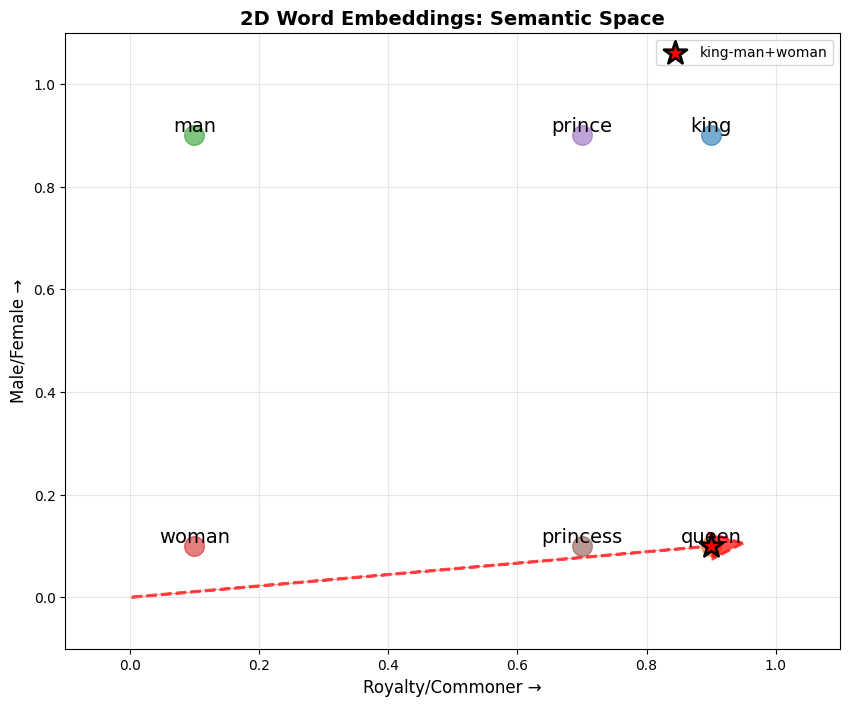

king - man + woman = [0.90, 0.10]
queen = [0.90, 0.10]

💡 The result is very close to 'queen'!


In [17]:
# Simple 2D word embeddings (normally 50-300 dimensions!)
# Dimension 1: royalty/commoner axis
# Dimension 2: male/female axis

embeddings_2d = {
    'king':   np.array([0.9, 0.9]),   # royal, male
    'queen':  np.array([0.9, 0.1]),   # royal, female
    'man':    np.array([0.1, 0.9]),   # common, male
    'woman':  np.array([0.1, 0.1]),   # common, female
    'prince': np.array([0.7, 0.9]),   # somewhat royal, male
    'princess': np.array([0.7, 0.1]), # somewhat royal, female
}

# Visualize
plt.figure(figsize=(10, 8))
for word, vec in embeddings_2d.items():
    plt.scatter(vec[0], vec[1], s=200, alpha=0.6)
    plt.annotate(word, (vec[0], vec[1]), fontsize=14, ha='center', va='bottom')

# Show the king - man + woman = queen relationship
king = embeddings_2d['king']
man = embeddings_2d['man']
woman = embeddings_2d['woman']
result = king - man + woman

plt.arrow(0, 0, result[0], result[1], head_width=0.05, head_length=0.05, 
          fc='red', ec='red', linewidth=2, linestyle='--', alpha=0.7)
plt.scatter(result[0], result[1], s=300, c='red', marker='*', 
            edgecolors='black', linewidths=2, label='king-man+woman', zorder=5)

plt.xlabel('Royalty/Commoner →', fontsize=12)
plt.ylabel('Male/Female →', fontsize=12)
plt.title('2D Word Embeddings: Semantic Space', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.show()

print(f"king - man + woman = [{result[0]:.2f}, {result[1]:.2f}]")
print(f"queen = [{embeddings_2d['queen'][0]:.2f}, {embeddings_2d['queen'][1]:.2f}]")
print(f"\n💡 The result is very close to 'queen'!")


### How Do We Get Word Embeddings?

There are different approaches:

**1. Pre-trained embeddings** (Word2Vec, GloVe, fastText)
- Trained on massive text corpora (billions of words)
- Ready to use!
- Examples: Word2Vec trained on Google News, GloVe trained on Wikipedia
   
**2. Learn them as part of your model** (modern approach)
- Start with **random vectors** (like we'll do below)
- During training, the neural network **adjusts these vectors** through backpropagation
- **How it works**: 
  - Initially: embeddings are random → bad predictions
  - Network makes predictions → calculates loss
  - Backpropagation computes gradients for EVERYTHING, including embeddings!
  - Embeddings get updated to reduce loss
  - After many iterations: embeddings capture meaningful patterns
- This is what GPT, BERT do!

**The key difference with our examples**: 
- In our demo, embeddings stay random (we don't train)
- In real models, embeddings are **learned parameters** that get optimized
- The network learns: "These word vectors should be similar if they appear in similar contexts"

Let's create a simple **Embedding Layer**:


In [18]:
class EmbeddingLayer:
    """
    Converts word IDs to dense vectors (embeddings).
    Think of this as a lookup table: word ID → vector
    """
    
    def __init__(self, vocab_size, embedding_dim):
        """
        Initialize the embedding matrix.
        
        vocab_size: number of words in vocabulary (e.g., 10,000)
        embedding_dim: size of each embedding vector (e.g., 50, 100, 300)
        """
        # STEP 1: Create embedding matrix (the lookup table)
        # Shape: (vocab_size, embedding_dim)
        # Each ROW is the embedding for one word
        # We initialize with small random numbers (not zeros!)
        self.embeddings = np.random.randn(vocab_size, embedding_dim) * 0.1
        
        # Why multiply by 0.1?
        # → Keep initial values small for better training stability
        # → If too large, can cause exploding gradients
        
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        
        # Example: If vocab_size=7 and embedding_dim=4, we have:
        #   Row 0 (word "the"):  [0.05, -0.02, 0.08, -0.01]
        #   Row 1 (word "cat"):  [-0.03, 0.07, -0.05, 0.02]
        #   Row 2 (word "sat"):  [0.01, -0.08, 0.03, -0.04]
        #   ... and so on
    
    def __call__(self, word_id):
        """
        Look up the embedding for a single word.
        
        word_id: integer ID of the word
        
        Returns: embedding vector (numpy array of shape (embedding_dim,))
        """
        # STEP 1: Index into the embedding matrix
        # This is just a lookup operation - very fast!
        # embeddings[word_id] → returns the row for that word
        return self.embeddings[word_id]
        
        # Example:
        # If word_id = 1 (word "cat"), returns embeddings[1, :]
        # → the entire row for "cat"
    
    def get_multiple(self, word_ids):
        """
        Look up embeddings for multiple words at once.
        
        word_ids: list of integer word IDs
        
        Returns: matrix of embeddings, shape (num_words, embedding_dim)
        """
        # STEP 1: Look up each word and stack results
        # [self.embeddings[idx] for idx in word_ids] creates a list of vectors
        # np.array(...) stacks them into a matrix
        return np.array([self.embeddings[idx] for idx in word_ids])
        
        # Example:
        # word_ids = [0, 1, 2] (words "the", "cat", "sat")
        # Returns a 3×4 matrix:
        #   [[0.05, -0.02, 0.08, -0.01],   ← "the"
        #    [-0.03, 0.07, -0.05, 0.02],   ← "cat"
        #    [0.01, -0.08, 0.03, -0.04]]   ← "sat"


# Example usage with detailed output
print("Creating Vocabulary and Embedding Layer")
print("="*60)

# STEP 1: Define vocabulary (words we know)
vocab = ['the', 'cat', 'sat', 'on', 'mat', 'dog', 'floor']
print(f"Vocabulary: {vocab}")
print(f"Vocabulary size: {len(vocab)} words")

# STEP 2: Create word-to-ID mapping
# This converts words to integers: "cat" → 1, "dog" → 5, etc.
word_to_id = {word: i for i, word in enumerate(vocab)}
print(f"\nWord-to-ID mapping:")
for word, idx in list(word_to_id.items())[:3]:
    print(f"  '{word}' → ID {idx}")
print("  ...")

# STEP 3: Create embedding layer
# 7 words, each represented as a 4-dimensional vector
embed = EmbeddingLayer(vocab_size=len(vocab), embedding_dim=4)
print(f"\n✓ Created embedding matrix: shape ({embed.vocab_size}, {embed.embedding_dim})")

# STEP 4: Look up embeddings for some words
print(f"\n{'='*60}")
print("Looking up word embeddings:")
print(f"{'='*60}")
for word in ['cat', 'dog', 'mat']:
    # Convert word to ID, then ID to embedding
    word_id = word_to_id[word]
    embedding = embed(word_id)  # This is the lookup!
    print(f"  '{word}' → ID {word_id} → vector {embedding}")

print(f"\n💡 Each word is now a {embed.embedding_dim}-dimensional vector!")
print(f"   • Dense representation (all values meaningful)")
print(f"   • In practice, we use 50-300 dimensions for richer representations")
print(f"   • During training, these vectors get adjusted to capture meaning!")


Creating Vocabulary and Embedding Layer
Vocabulary: ['the', 'cat', 'sat', 'on', 'mat', 'dog', 'floor']
Vocabulary size: 7 words

Word-to-ID mapping:
  'the' → ID 0
  'cat' → ID 1
  'sat' → ID 2
  ...

✓ Created embedding matrix: shape (7, 4)

Looking up word embeddings:
  'cat' → ID 1 → vector [-0.18868044 -0.08388693 -0.13182539 -0.02804925]
  'dog' → ID 5 → vector [-0.2403528   0.1603109  -0.20592456  0.22622401]
  'mat' → ID 4 → vector [-0.04179481  0.10050733 -0.07728075 -0.07350749]

💡 Each word is now a 4-dimensional vector!
   • Dense representation (all values meaningful)
   • In practice, we use 50-300 dimensions for richer representations
   • During training, these vectors get adjusted to capture meaning!


### **Exercise 1: Build Your Own Vocabulary**
Extend the vocabulary with new sentences and create proper word-to-id mappings.

```python
# Add these sentences to the existing corpus:
new_sentences = [
    "the mouse ate the cheese",
    "the bird flew to the tree", 
    "the dog chased the cat"
]

# Tasks:
# 1. Combine with existing sentences
# 2. Build a complete vocabulary (unique words only)
# 3. Create word_to_id and id_to_word dictionaries
# 4. Print all training pairs (context → next_word)
```

**Why?**: 
- Understand vocabulary construction
- Practice dictionary creation
- See how dataset size affects coverage

In [19]:
# your code here
# Combine sentences
new_sentences = [
    "the mouse ate the cheese",
    "the bird flew to the tree",
    "the dog chased the cat",
]

all_sentences = sentences + new_sentences

# Build vocabulary
vocab_set = set()
for sentence in all_sentences:
    vocab_set.update(sentence.split())

vocab = sorted(list(vocab_set))

# Create mappings
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}

print(f"Vocabulary size: {len(vocab)}")
print(f"Vocabulary: {vocab}\n")

# Generate all training pairs
print("Training pairs:")
print("=" * 60)
for sentence in all_sentences:
    words = sentence.split()
    for i in range(len(words) - 1):
        context = " ".join(words[: i + 1])
        next_word = words[i + 1]
        print(f"  '{context:<30}' → '{next_word}'")

Vocabulary size: 19
Vocabulary: ['ate', 'bird', 'branch', 'cat', 'chased', 'cheese', 'dog', 'flew', 'floor', 'king', 'mat', 'mouse', 'on', 'queen', 'sat', 'the', 'throne', 'to', 'tree']

Training pairs:
  'the                           ' → 'cat'
  'the cat                       ' → 'sat'
  'the cat sat                   ' → 'on'
  'the cat sat on                ' → 'the'
  'the cat sat on the            ' → 'mat'
  'the                           ' → 'dog'
  'the dog                       ' → 'sat'
  'the dog sat                   ' → 'on'
  'the dog sat on                ' → 'the'
  'the dog sat on the            ' → 'floor'
  'the                           ' → 'bird'
  'the bird                      ' → 'sat'
  'the bird sat                  ' → 'on'
  'the bird sat on               ' → 'the'
  'the bird sat on the           ' → 'branch'
  'the                           ' → 'queen'
  'the queen                     ' → 'sat'
  'the queen sat                 ' → 'on'
  'the queen sat on

### Static vs Contextual Embeddings

**A crucial distinction!**

**Static Embeddings** (Word2Vec, GloVe, what we showed above)
- Each word has **ONE fixed vector**, regardless of context
- "bank" → always the same vector
- **Problem**: "I went to the **bank** to deposit money" vs "I sat by the river **bank**"
  - Same word, different meanings!
  - Static embeddings can't distinguish

**Contextual Embeddings** (ELMo, BERT, GPT)
- Each word gets a **different vector depending on context**!
- "bank" in financial context → one vector
- "bank" in river context → different vector
- How? The model looks at surrounding words to create the embedding

**Example**:
```
Static (Word2Vec):
  "bank" → always [0.2, 0.5, 0.8, ...]

Contextual (BERT):
  "I went to the bank" → "bank" = [0.9, 0.1, 0.3, ...]  (financial)
  "river bank"         → "bank" = [0.1, 0.8, 0.2, ...]  (geological)
```

**Modern language models (GPT, BERT) produce contextual embeddings!**
- They use Transformers with attention
- Each word "looks at" its context to determine its meaning
- This is why they're so powerful!

**In this notebook**:
- First, we'll use **static embeddings** (simpler to understand)
- Then with **Transformers**, we'll see how they naturally produce **contextual** representations through attention!


## Part 3: The Problem with MLPs for Sequences

### Why Can't We Just Use MLPs?

**Problem 1: Fixed Input Size**
- MLP expects fixed number of inputs (e.g., 3 numbers)
- Sentences have variable length!
  - "Hello" = 1 word
  - "The cat sat on the mat" = 6 words

**Problem 2: No Sequential Memory**
- MLP processes all inputs at once
- Doesn't remember what came before
- Word order is lost!

**Problem 3: Can't Share Knowledge**
- If "cat" appears at position 1 or position 5, MLP treats it differently
- Wasteful! "cat" should be recognized the same way regardless of position

### Solution: Recurrent Neural Networks (RNNs)! 🔄


## Part 4: Recurrent Neural Networks (RNNs)

### The Big Idea: Memory + Sequential Processing

An RNN processes a sequence **one word at a time**, maintaining a **hidden state** (memory):

```
Input:  ["The",  "cat",  "sat",  "on",   "the",  "mat"]
         ↓       ↓       ↓       ↓        ↓       ↓
Hidden: [h₀] → [h₁] → [h₂] → [h₃] → [h₄] → [h₅]
```

At each step:
- **Input**: current word embedding
- **Previous memory**: hidden state from previous step
- **Output**: new hidden state (updated memory)

**Formula**: `h_t = tanh(W_hh × h_{t-1} + W_xh × x_t + b)`

Where:
- `h_t` = new hidden state (memory)
- `h_{t-1}` = previous hidden state
- `x_t` = current word embedding
- `W_hh`, `W_xh`, `b` = learned parameters (weights and bias)


### Visualizing an RNN


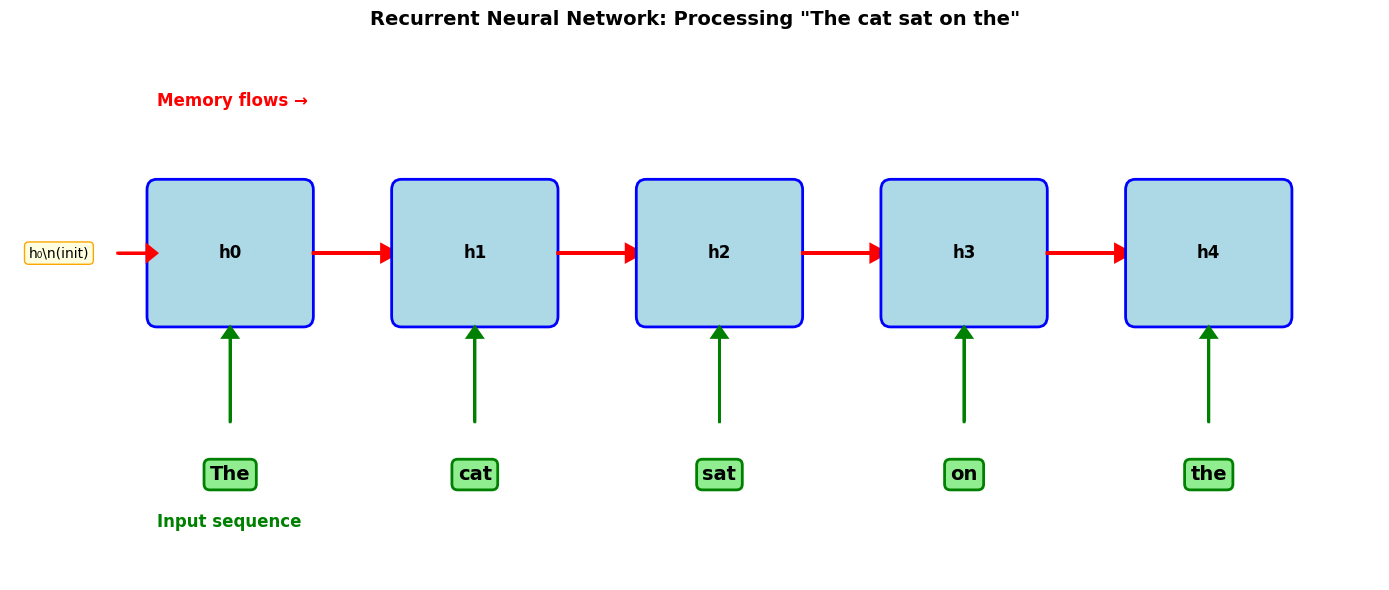

💡 Key insight: The hidden state h_t contains information
   about ALL previous words in the sequence!


In [20]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 6))

# Words to process
words = ['The', 'cat', 'sat', 'on', 'the']
n_words = len(words)

# Draw RNN cells
for i in range(n_words):
    x = i * 2.5 + 0.5
    
    # RNN cell (hidden state)
    cell = FancyBboxPatch((x, 2), 1.5, 1.2, 
                          boxstyle="round,pad=0.1", 
                          edgecolor='blue', facecolor='lightblue', linewidth=2)
    ax.add_patch(cell)
    ax.text(x + 0.75, 2.6, f'h{i}', ha='center', va='center', 
            fontsize=12, fontweight='bold')
    
    # Input word
    ax.text(x + 0.75, 0.5, words[i], ha='center', va='center', 
            fontsize=14, fontweight='bold', 
            bbox=dict(boxstyle='round', facecolor='lightgreen', edgecolor='green', linewidth=2))
    
    # Arrow from word to cell
    ax.arrow(x + 0.75, 1.0, 0, 0.8, head_width=0.15, head_length=0.1, 
             fc='green', ec='green', linewidth=2)
    
    # Arrow to next cell (memory flow)
    if i < n_words - 1:
        ax.arrow(x + 1.6, 2.6, 0.7, 0, head_width=0.15, head_length=0.15, 
                 fc='red', ec='red', linewidth=2.5)

# Labels
ax.text(0.5, 4.0, 'Memory flows →', fontsize=12, color='red', fontweight='bold')
ax.text(0.5, 0, 'Input sequence', fontsize=12, color='green', fontweight='bold')

# Initial hidden state
ax.text(-0.5, 2.6, 'h₀\\n(init)', ha='center', va='center', 
        fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))
ax.arrow(0.1, 2.6, 0.3, 0, head_width=0.15, head_length=0.1, 
         fc='red', ec='red', linewidth=2)

ax.set_xlim(-1, 13)
ax.set_ylim(-0.5, 4.5)
ax.axis('off')
ax.set_title('Recurrent Neural Network: Processing "The cat sat on the"', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("💡 Key insight: The hidden state h_t contains information")
print("   about ALL previous words in the sequence!")


### Building a Simple RNN


In [21]:
class EmbeddingLayer:
    """
    Converts word IDs to dense vectors (embeddings).
    Think of this as a lookup table: word ID → vector
    """

    def __init__(self, vocab_size, embedding_dim):
        """
        Initialize the embedding matrix.

        vocab_size: number of words in vocabulary (e.g., 10,000)
        embedding_dim: size of each embedding vector (e.g., 50, 100, 300)
        """
        # STEP 1: Create embedding matrix (the lookup table)
        # Shape: (vocab_size, embedding_dim)
        # Each ROW is the embedding for one word
        # We initialize with small random numbers (not zeros!)
        self.embeddings = np.random.randn(vocab_size, embedding_dim) * 0.1

        # Why multiply by 0.1?
        # → Keep initial values small for better training stability
        # → If too large, can cause exploding gradients

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim

        # Example: If vocab_size=7 and embedding_dim=4, we have:
        #   Row 0 (word "the"):  [0.05, -0.02, 0.08, -0.01]
        #   Row 1 (word "cat"):  [-0.03, 0.07, -0.05, 0.02]
        #   Row 2 (word "sat"):  [0.01, -0.08, 0.03, -0.04]
        #   ... and so on

    def __call__(self, word_id):
        """
        Look up the embedding for a single word.

        word_id: integer ID of the word

        Returns: embedding vector (numpy array of shape (embedding_dim,))
        """
        # STEP 1: Index into the embedding matrix
        # This is just a lookup operation - very fast!
        # embeddings[word_id] → returns the row for that word
        return self.embeddings[word_id]

        # Example:
        # If word_id = 1 (word "cat"), returns embeddings[1, :]
        # → the entire row for "cat"

    def get_multiple(self, word_ids):
        """
        Look up embeddings for multiple words at once.

        word_ids: list of integer word IDs

        Returns: matrix of embeddings, shape (num_words, embedding_dim)
        """
        # STEP 1: Look up each word and stack results
        # [self.embeddings[idx] for idx in word_ids] creates a list of vectors
        # np.array(...) stacks them into a matrix
        return np.array([self.embeddings[idx] for idx in word_ids])

        # Example:
        # word_ids = [0, 1, 2] (words "the", "cat", "sat")
        # Returns a 3×4 matrix:
        #   [[0.05, -0.02, 0.08, -0.01],   ← "the"
        #    [-0.03, 0.07, -0.05, 0.02],   ← "cat"
        #    [0.01, -0.08, 0.03, -0.04]]   ← "sat"


# Example usage with detailed output
print("Creating Vocabulary and Embedding Layer")
print("=" * 60)

# STEP 1: Define vocabulary (words we know)
vocab = ["the", "cat", "sat", "on", "mat", "dog", "floor"]
print(f"Vocabulary: {vocab}")
print(f"Vocabulary size: {len(vocab)} words")

# STEP 2: Create word-to-ID mapping
# This converts words to integers: "cat" → 1, "dog" → 5, etc.
word_to_id = {word: i for i, word in enumerate(vocab)}
print(f"\nWord-to-ID mapping:")
for word, idx in list(word_to_id.items())[:3]:
    print(f"  '{word}' → ID {idx}")
print("  ...")

# STEP 3: Create embedding layer
# 7 words, each represented as a 4-dimensional vector
embed = EmbeddingLayer(vocab_size=len(vocab), embedding_dim=4)
print(
    f"\n✓ Created embedding matrix: shape ({embed.vocab_size}, {embed.embedding_dim})"
)

# STEP 4: Look up embeddings for some words
print(f"\n{'='*60}")
print("Looking up word embeddings:")
print(f"{'='*60}")
for word in ["cat", "dog", "mat"]:
    # Convert word to ID, then ID to embedding
    word_id = word_to_id[word]
    embedding = embed(word_id)  # This is the lookup!
    print(f"  '{word}' → ID {word_id} → vector {embedding}")

print(f"\n💡 Each word is now a {embed.embedding_dim}-dimensional vector!")
print(f"   • Dense representation (all values meaningful)")
print(f"   • In practice, we use 50-300 dimensions for richer representations")
print(f"   • During training, these vectors get adjusted to capture meaning!")

Creating Vocabulary and Embedding Layer
Vocabulary: ['the', 'cat', 'sat', 'on', 'mat', 'dog', 'floor']
Vocabulary size: 7 words

Word-to-ID mapping:
  'the' → ID 0
  'cat' → ID 1
  'sat' → ID 2
  ...

✓ Created embedding matrix: shape (7, 4)

Looking up word embeddings:
  'cat' → ID 1 → vector [-0.01528392  0.00420563 -0.11102178 -0.07467248]
  'dog' → ID 5 → vector [ 0.08500156 -0.02760681 -0.08916461 -0.01006496]
  'mat' → ID 4 → vector [-0.25448998  0.00649524 -0.08751797  0.09652814]

💡 Each word is now a 4-dimensional vector!
   • Dense representation (all values meaningful)
   • In practice, we use 50-300 dimensions for richer representations
   • During training, these vectors get adjusted to capture meaning!


In [22]:
class SimpleRNN:
    """A simple recurrent neural network."""
    
    def __init__(self, input_dim, hidden_dim):
        self.hidden_dim = hidden_dim
        
        # Weight matrices - these are the LEARNABLE parameters
        self.W_xh = np.random.randn(input_dim, hidden_dim) * 0.01   # input to hidden
        self.W_hh = np.random.randn(hidden_dim, hidden_dim) * 0.01  # hidden to hidden  
        self.b_h = np.zeros((1, hidden_dim))                        # bias
        
        # Think of these as:
        # W_xh: "How to transform the current word into memory contribution"
        # W_hh: "How to carry forward previous memory"
        # b_h: "Default memory baseline"
    
    def step(self, x_t, h_prev):
        """
        One step of the RNN - the core computation!
        
        x_t: current input (word embedding), shape (1, input_dim)
        h_prev: previous hidden state (memory), shape (1, hidden_dim)
        
        Returns: new hidden state (updated memory), shape (1, hidden_dim)
        """
        # STEP 1: Process current input
        # x_t @ W_xh → "What does the current word contribute?"
        input_contribution = np.dot(x_t, self.W_xh)
        
        # STEP 2: Process previous memory
        # h_prev @ W_hh → "What do we remember from before?"
        memory_contribution = np.dot(h_prev, self.W_hh)
        
        # STEP 3: Combine both sources of information
        combined = input_contribution + memory_contribution + self.b_h
        
        # STEP 4: Apply non-linearity (tanh squashes to [-1, 1])
        # This allows the RNN to learn complex patterns
        h_t = np.tanh(combined)
        
        # h_t now contains information about:
        # - The current word (through input_contribution)
        # - All previous words (through memory_contribution)
        
        return h_t
    
    def forward(self, x_sequence):
        """
        Process entire sequence, one word at a time.
        
        x_sequence: list of word embeddings (numpy arrays)
        
        Returns: list of hidden states (one per input word)
        """
        # Initialize hidden state to zeros (no memory at start)
        h = np.zeros((1, self.hidden_dim))
        hidden_states = []
        
        # Process each word in sequence
        # At each step: h contains memory of all previous words
        for i, x_t in enumerate(x_sequence):
            # Update hidden state (memory) with current word
            h = self.step(x_t.reshape(1, -1), h)
            hidden_states.append(h)
            # Now h contains info about words 0 through i
        
        return hidden_states


# Test the RNN with detailed output
print("Testing SimpleRNN:")
print("="*60)

# Create RNN: 4D input (word embeddings), 8D hidden state
rnn = SimpleRNN(input_dim=4, hidden_dim=8)

# Get embeddings for "the cat sat"
sentence = ['the', 'cat', 'sat']
word_ids = [word_to_id[w] for w in sentence]
embeddings = embed.get_multiple(word_ids)

print(f"Input sequence: {sentence}")
print(f"Embedding dimension: {embeddings.shape[1]}")
print(f"Hidden state dimension: {rnn.hidden_dim}")

# Process sequence step by step
print(f"\n{'='*60}")
print("PROCESSING SEQUENCE STEP BY STEP:")
print(f"{'='*60}\n")

h = np.zeros((1, rnn.hidden_dim))
for i, (word, emb) in enumerate(zip(sentence, embeddings)):
    print(f"Step {i+1}: Processing word '{word}'")
    print(f"  Input embedding: {emb[:4]} ... (first 4 dims)")
    print(f"  Previous hidden state: {h[0][:4]} ... (first 4 dims)")
    
    # Process this step
    h = rnn.step(emb.reshape(1, -1), h)
    
    print(f"  → New hidden state: {h[0][:4]} ... (first 4 dims)")
    print(f"  → This hidden state now contains info about: {sentence[:i+1]}")
    print()

print(f"💡 Key insight: Each hidden state is a 'summary' of everything seen so far!")
print(f"   • h1 summarizes 'the'")
print(f"   • h2 summarizes 'the cat'")
print(f"   • h3 summarizes 'the cat sat'")
print(f"\n   The final hidden state contains information about the ENTIRE sequence!")


Testing SimpleRNN:
Input sequence: ['the', 'cat', 'sat']
Embedding dimension: 4
Hidden state dimension: 8

PROCESSING SEQUENCE STEP BY STEP:

Step 1: Processing word 'the'
  Input embedding: [ 0.04678555 -0.04146966  0.0369802   0.01662519] ... (first 4 dims)
  Previous hidden state: [0. 0. 0. 0.] ... (first 4 dims)
  → New hidden state: [-0.00184546 -0.0014401   0.00112103  0.00104589] ... (first 4 dims)
  → This hidden state now contains info about: ['the']

Step 2: Processing word 'cat'
  Input embedding: [-0.01528392  0.00420563 -0.11102178 -0.07467248] ... (first 4 dims)
  Previous hidden state: [-0.00184546 -0.0014401   0.00112103  0.00104589] ... (first 4 dims)
  → New hidden state: [ 0.00072756  0.00087722 -0.00163418 -0.00214931] ... (first 4 dims)
  → This hidden state now contains info about: ['the', 'cat']

Step 3: Processing word 'sat'
  Input embedding: [ 0.14065434 -0.00543701  0.04592239 -0.04332676] ... (first 4 dims)
  Previous hidden state: [ 0.00072756  0.00087722 -

### **Exercise: Compare Sequence Lengths**
Test how RNN handles different sequence lengths.

```python
# Test sentences of different lengths:
short_seq = ['cat']
medium_seq = ['the', 'cat', 'sat']
long_seq = ['the', 'cat', 'sat', 'on', 'the', 'mat']

# Tasks:
# 1. Process all three through the RNN
# 2. Compare final hidden states (shape and values)
# 3. Plot how hidden state values change across time steps
# 4. What happens to the magnitude of h_t as sequence gets longer?
```

**Why?**:
- Understand variable-length sequence handling
- Observe potential vanishing/exploding gradient issues
- Practice working with sequences

SHORT (1 words): ['cat']
  Final hidden shape: (1, 8)
  Final hidden L2 norm: 0.0034

MEDIUM (3 words): ['the', 'cat', 'sat']
  Final hidden shape: (1, 8)
  Final hidden L2 norm: 0.0072

LONG (6 words): ['the', 'cat', 'sat', 'on', 'the', 'mat']
  Final hidden shape: (1, 8)
  Final hidden L2 norm: 0.0130



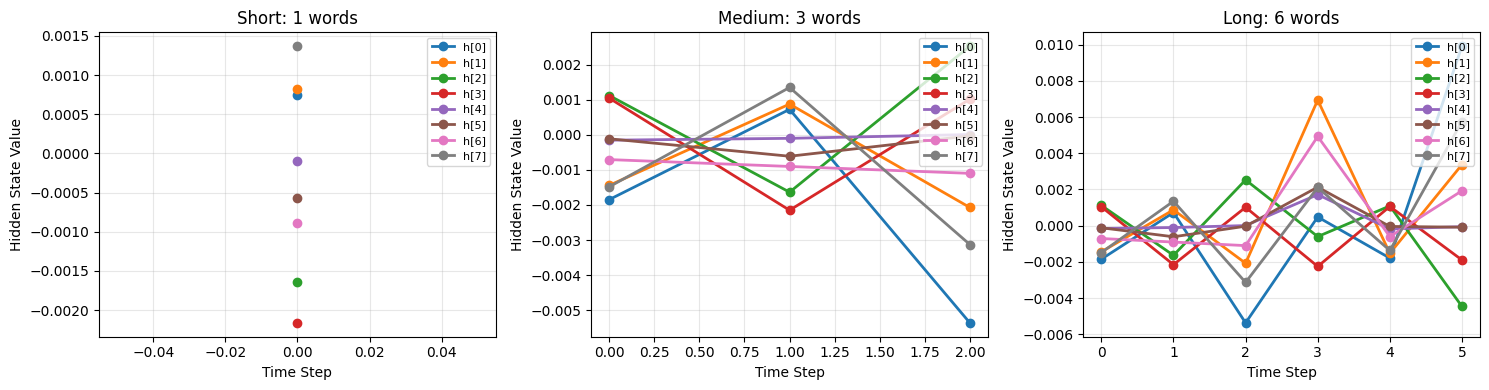

Hidden state magnitude growth:
  short: [np.float64(0.0034059069362304155)]
  medium: [np.float64(0.0032490751092920764), np.float64(0.0034072472538787062), np.float64(0.007174292299236169)]
  long: [np.float64(0.0032490751092920764), np.float64(0.0034072472538787062), np.float64(0.007174292299236169), np.float64(0.009485248391433655), np.float64(0.003177537642816072), np.float64(0.013031965707570895)]


In [23]:
# your code here

# Define test sequences
short_seq = ["cat"]
medium_seq = ["the", "cat", "sat"]
long_seq = ["the", "cat", "sat", "on", "the", "mat"]

sequences = {"short": short_seq, "medium": medium_seq, "long": long_seq}

# Process each sequence
results = {}
for name, seq in sequences.items():
    # Get embeddings
    word_ids = [word_to_id[w] for w in seq]
    embeddings = embed.get_multiple(word_ids)

    # Process through RNN
    hidden_states = rnn.forward(embeddings)

    # Store results
    results[name] = {
        "sequence": seq,
        "hidden_states": hidden_states,
        "final_hidden": hidden_states[-1],
    }

    print(f"{name.upper()} ({len(seq)} words): {seq}")
    print(f"  Final hidden shape: {hidden_states[-1].shape}")
    print(f"  Final hidden L2 norm: {np.linalg.norm(hidden_states[-1]):.4f}")
    print()

# Plot hidden state evolution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, data) in enumerate(results.items()):
    hidden_matrix = np.array([h[0] for h in data["hidden_states"]])

    axes[idx].plot(hidden_matrix, marker="o", linewidth=2)
    axes[idx].set_title(f'{name.capitalize()}: {len(data["sequence"])} words')
    axes[idx].set_xlabel("Time Step")
    axes[idx].set_ylabel("Hidden State Value")
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(
        [f"h[{i}]" for i in range(rnn.hidden_dim)], loc="upper right", fontsize=8
    )

plt.tight_layout()
plt.show()

# Compare magnitudes
print("Hidden state magnitude growth:")
for name, data in results.items():
    norms = [np.linalg.norm(h) for h in data["hidden_states"]]
    print(f"  {name}: {norms}")

## Part 5: RNN Language Model

Now let's build a complete **RNN Language Model** that predicts the next word!

### Architecture:

```
Input word → Embedding → RNN → Output layer → Probability distribution over vocabulary
```

At each step:
1. Convert word to embedding
2. Update RNN hidden state
3. Predict probability for each possible next word
4. Choose most likely word (or sample)


In [24]:
def softmax(x):
    """
    Convert raw scores (logits) to probabilities.
    
    This ensures all values are positive and sum to 1.
    """
    # STEP 1: Exponentiate (make all values positive)
    # Subtract max(x) first for numerical stability
    # Why? Prevents overflow if x has very large values
    exp_x = np.exp(x - np.max(x))
    
    # STEP 2: Normalize (make values sum to 1)
    # Divide each value by the sum of all values
    # Result: valid probability distribution!
    return exp_x / exp_x.sum(axis=-1, keepdims=True)
    
    # Example:
    # Input logits: [2.0, 1.0, 0.1]
    # After exp: [7.39, 2.72, 1.11] (all positive)
    # After normalize: [0.66, 0.24, 0.10] (sum = 1.0)


class RNNLanguageModel:
    """
    A complete RNN-based language model for next word prediction.
    
    Architecture: Embeddings → RNN → Output Layer → Probabilities
    """
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        """
        Initialize all components of the language model.
        
        vocab_size: number of words we can predict
        embedding_dim: size of word vectors
        hidden_dim: size of RNN hidden state (memory)
        """
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        
        # COMPONENT 1: Embedding layer
        # Converts word IDs → dense vectors
        self.embedding = EmbeddingLayer(vocab_size, embedding_dim)
        
        # COMPONENT 2: RNN layer
        # Processes sequence with memory
        self.rnn = SimpleRNN(embedding_dim, hidden_dim)
        
        # COMPONENT 3: Output layer (prediction head)
        # Converts final hidden state → scores for each word in vocabulary
        # Shape: (hidden_dim, vocab_size)
        # Think: "For each hidden state dimension, how does it contribute to predicting each word?"
        self.W_out = np.random.randn(hidden_dim, vocab_size) * 0.01
        self.b_out = np.zeros((1, vocab_size))
    
    def predict_next(self, word_ids):
        """
        Predict the next word given a sequence of words.
        
        word_ids: list of word IDs (e.g., [0, 1] for "the cat")
        
        Returns: probability distribution over vocabulary (array of vocab_size probabilities)
        """
        # STEP 1: Convert word IDs to embeddings
        # Input: [0, 1] (IDs for "the", "cat")
        # Output: matrix of shape (2, embedding_dim)
        embeddings = self.embedding.get_multiple(word_ids)
        
        # STEP 2: Process sequence through RNN
        # RNN reads embeddings one by one, updating hidden state
        # Input: (2, embedding_dim) - embeddings for "the", "cat"
        # Output: list of hidden states, one per word
        hidden_states = self.rnn.forward(embeddings)
        
        # STEP 3: Extract final hidden state
        # This contains information about the ENTIRE sequence
        # After seeing "the cat", what do we know?
        final_hidden = hidden_states[-1]  # Shape: (1, hidden_dim)
        
        # STEP 4: Compute prediction scores (logits) for each word
        # Matrix multiplication: (1, hidden_dim) @ (hidden_dim, vocab_size)
        # Result: (1, vocab_size) - a score for each possible next word
        # Higher score = more likely to be next word
        logits = np.dot(final_hidden, self.W_out) + self.b_out
        
        # STEP 5: Convert scores to probabilities using softmax
        # Logits can be any value (positive or negative)
        # Probabilities must be in [0, 1] and sum to 1
        probs = softmax(logits)
        
        # Return 1D array of probabilities
        return probs[0]


# Create and test the language model with detailed output
print("Building RNN Language Model")
print("="*60)

# Create the model
lm = RNNLanguageModel(vocab_size=len(vocab), embedding_dim=4, hidden_dim=8)

print(f"Model components:")
print(f"  • Vocabulary size: {lm.vocab_size} words")
print(f"  • Embedding dimension: {lm.embedding_dim}")
print(f"  • RNN hidden dimension: {lm.hidden_dim}")
print(f"  • Output layer: {lm.hidden_dim} → {lm.vocab_size} (hidden → vocab)")

# Test: Predict next word after "the cat"
print(f"\n{'='*60}")
print("Testing: Next Word Prediction")
print(f"{'='*60}")

context = ['the', 'cat']
context_ids = [word_to_id[w] for w in context]

print(f"\nInput context: '{' '.join(context)}'")
print(f"Word IDs: {context_ids}")

print(f"\nProcessing through model:")
print(f"  1. Convert words to embeddings: {len(context)} words → {lm.embedding_dim}D vectors")
print(f"  2. Process through RNN: sequence → hidden state")
print(f"  3. Predict next word: hidden state → {lm.vocab_size} probabilities")

# Get predictions
probs = lm.predict_next(context_ids)

print(f"\n{'='*60}")
print(f"Next word predictions (probabilities):")
print(f"{'='*60}")
for word, prob in zip(vocab, probs):
    bar = '█' * int(prob * 100)
    print(f"  {word:8} : {prob:.4f} {bar}")

print(f"\n💡 Key insights:")
print(f"   • All probabilities sum to 1.0: {probs.sum():.4f}")
print(f"   • Model assigns a probability to EACH word in vocabulary")
print(f"   • Currently random (not trained) → predictions are meaningless")
print(f"   • After training: model learns which words typically follow 'the cat'!")
print(f"   • Training adjusts embeddings + RNN weights + output weights")


Building RNN Language Model
Model components:
  • Vocabulary size: 7 words
  • Embedding dimension: 4
  • RNN hidden dimension: 8
  • Output layer: 8 → 7 (hidden → vocab)

Testing: Next Word Prediction

Input context: 'the cat'
Word IDs: [0, 1]

Processing through model:
  1. Convert words to embeddings: 2 words → 4D vectors
  2. Process through RNN: sequence → hidden state
  3. Predict next word: hidden state → 7 probabilities

Next word predictions (probabilities):
  the      : 0.1429 ██████████████
  cat      : 0.1429 ██████████████
  sat      : 0.1429 ██████████████
  on       : 0.1429 ██████████████
  mat      : 0.1429 ██████████████
  dog      : 0.1428 ██████████████
  floor    : 0.1429 ██████████████

💡 Key insights:
   • All probabilities sum to 1.0: 1.0000
   • Model assigns a probability to EACH word in vocabulary
   • Currently random (not trained) → predictions are meaningless
   • After training: model learns which words typically follow 'the cat'!
   • Training adjusts em

### Problems with Simple RNNs

RNNs are powerful, but they have issues:

**1. Vanishing Gradients** 📉
- Information from early words gets "forgotten"
- Gradients become very small when backpropagating through many steps
- Hard to learn long-range dependencies

**Example**: In "The cat that chased the mouse **was** tired", the verb "was" must agree with "cat" (not "mouse"), which is far back.

**2. Sequential Processing** 🐌
- Must process words one at a time
- Can't parallelize → slow training!

**Solutions**:
- **LSTM/GRU**: Better RNN architectures with gating mechanisms (control what to remember/forget)
- **Transformers**: Completely different approach (parallel + attention)!


## Part 6: Transformers - The Revolution! 🚀

### The Big Idea: Attention as Communication

**Think of attention as a communication mechanism!**

Imagine a room full of people (words), and each person wants to gather information:
- Each person can **broadcast** what they know
- Each person can **listen** to others and decide who to pay attention to
- Everyone communicates **at the same time** (parallel!)

This is exactly what attention does!

**Key insight**: Instead of processing words sequentially (like RNNs), what if we could:
1. Process ALL words **in parallel**
2. Let each word **communicate with** all other words
3. Let each word decide which other words are important
4. Share information directly between any two words

This is **Attention** - a communication system where tokens exchange information!

### The Problem Transformers Solve

**RNN limitation**: 
- "The cat that chased the mouse that ate the cheese **was** tired"
- To understand "was", we need to look back at "cat" (the subject)
- RNN has to pass information through many steps → information gets lost!
- Like a game of telephone: message degrades

**Transformer solution**:
- Every word can directly "look at" every other word!
- "was" can directly attend to "cat", even if they're far apart
- No information bottleneck!
- Like everyone in a room talking directly to each other


### Self-Attention vs Cross-Attention

**Two types of attention:**

**1. Self-Attention** (what we'll focus on)
- Words attend to **other words in the SAME sequence**
- Example: In "The cat sat", each word looks at the other words in this sentence
- Use case: Understanding relationships within a sentence
- **This is what we'll implement below!**

**2. Cross-Attention** (used in translation)
- Words in one sequence attend to words in a **DIFFERENT sequence**
- Example: When translating, Spanish words attend to English words
- Use case: Connecting source and target in encoder-decoder models

### How Self-Attention Works

**Example**: "The cat sat on the mat"

When processing "sat", it needs to gather information:
- Looks at "cat" (the subject - who sat?)
- Looks at "on" (what came after - sat where?)
- Looks at itself "sat" (what am I?)
- Can ignore less relevant words like "the"

**Attention lets each word gather relevant information from all other words!**

### The Attention Mechanism: Query, Key, Value

For each word, attention computes three vectors:

1. **Query (Q)**: "What am I looking for?" (what information does this word need?)
2. **Key (K)**: "What do I offer?" (what information can this word provide?)
3. **Value (V)**: "What information do I contain?" (the actual information to share)

**The Communication Process:**
1. **Broadcasting**: Each word broadcasts its Key and Value ("Here's what I have!")
2. **Matching**: Each word's Query is compared with all Keys → attention scores ("Who has what I need?")
3. **Gathering**: Use scores to take a weighted sum of all Values ("Let me collect relevant info")
4. **Result**: Each word gets a context-aware representation!

**Formula**: `Attention(Q, K, V) = softmax(Q·K^T / √d) × V`

Think of it as:
- **Q·K^T**: "How relevant is each word to my query?" (similarity scores)
- **softmax(...)**: "Convert to probabilities (attention weights)"
- **× V**: "Gather information from relevant words" (weighted sum)

Let's visualize this!


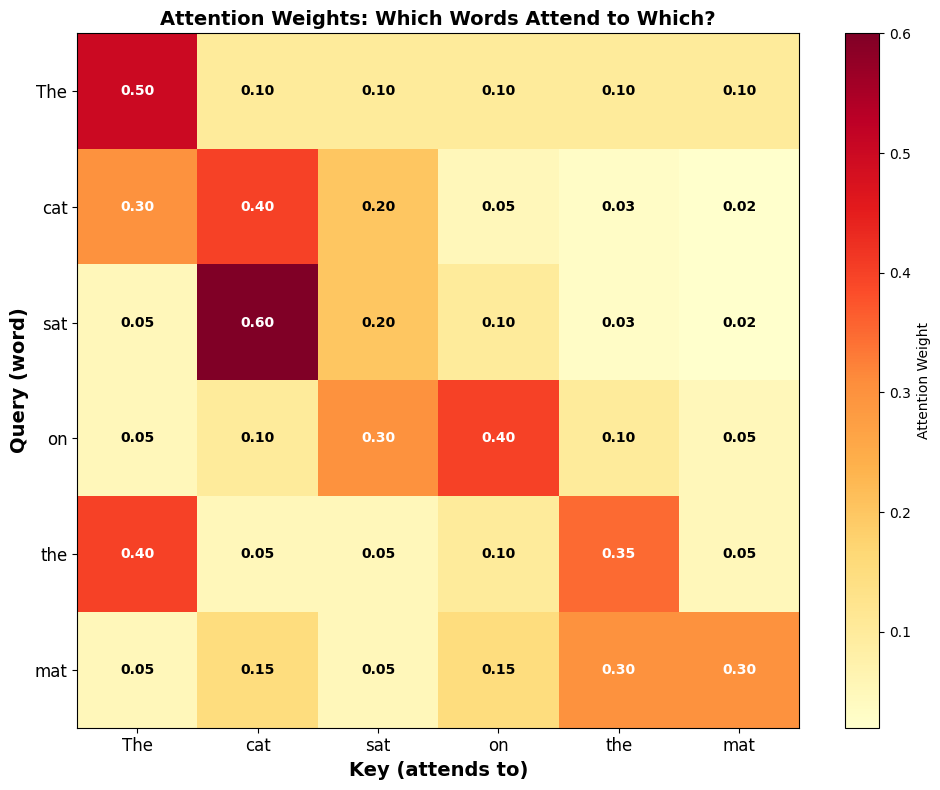

💡 Key observations:
   • 'sat' strongly attends to 'cat' (0.6) - finding the subject!
   • 'mat' attends to 'the' (0.3) - understanding 'the mat' as a phrase
   • Each word can look at ANY other word - no sequential bottleneck!


In [25]:
# Visualize attention weights
sentence_words = ['The', 'cat', 'sat', 'on', 'the', 'mat']

# Simulated attention weights (who attends to whom)
# Rows = query word, Columns = key word (what it attends to)
attention_weights = np.array([
    [0.5, 0.1, 0.1, 0.1, 0.1, 0.1],  # "The" mostly attends to itself
    [0.3, 0.4, 0.2, 0.05, 0.03, 0.02],  # "cat" attends to "The" and itself
    [0.05, 0.6, 0.2, 0.1, 0.03, 0.02],  # "sat" strongly attends to "cat" (subject!)
    [0.05, 0.1, 0.3, 0.4, 0.1, 0.05],  # "on" attends to "sat" and itself
    [0.4, 0.05, 0.05, 0.1, 0.35, 0.05],  # "the" (second) attends to first "the"
    [0.05, 0.15, 0.05, 0.15, 0.3, 0.3],  # "mat" attends to "the" and "on"
])

# Plot attention heatmap
plt.figure(figsize=(10, 8))
plt.imshow(attention_weights, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Attention Weight')

# Labels
plt.xticks(range(len(sentence_words)), sentence_words, fontsize=12)
plt.yticks(range(len(sentence_words)), sentence_words, fontsize=12)
plt.xlabel('Key (attends to)', fontsize=14, fontweight='bold')
plt.ylabel('Query (word)', fontsize=14, fontweight='bold')
plt.title('Attention Weights: Which Words Attend to Which?', fontsize=14, fontweight='bold')

# Add values in cells
for i in range(len(sentence_words)):
    for j in range(len(sentence_words)):
        text = plt.text(j, i, f'{attention_weights[i, j]:.2f}',
                       ha="center", va="center", color="black" if attention_weights[i, j] < 0.3 else "white",
                       fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("💡 Key observations:")
print("   • 'sat' strongly attends to 'cat' (0.6) - finding the subject!")
print("   • 'mat' attends to 'the' (0.3) - understanding 'the mat' as a phrase")
print("   • Each word can look at ANY other word - no sequential bottleneck!")


### Building a Simple Attention Layer


In [26]:
class SimpleAttention:
    """
    A simplified self-attention mechanism.
    
    Core idea: Let each word gather information from all other words.
    """
    
    def __init__(self, embed_dim):
        """
        Initialize the attention mechanism.
        
        embed_dim: dimensionality of word embeddings
        """
        self.embed_dim = embed_dim
        
        # Three transformation matrices: one each for Query, Key, Value
        # These are LEARNABLE parameters that get optimized during training
        
        # W_q: transforms embeddings into "queries" (what info am I looking for?)
        self.W_q = np.random.randn(embed_dim, embed_dim) * 0.01
        
        # W_k: transforms embeddings into "keys" (what info do I offer?)
        self.W_k = np.random.randn(embed_dim, embed_dim) * 0.01
        
        # W_v: transforms embeddings into "values" (what info do I contain?)
        self.W_v = np.random.randn(embed_dim, embed_dim) * 0.01
    
    def forward(self, x):
        """
        Apply self-attention to a sequence of embeddings.
        
        x: input embeddings, shape (seq_len, embed_dim)
           e.g., (3, 4) for "the cat sat" with 4D embeddings
        
        Returns: 
          - output: context-aware representations, shape (seq_len, embed_dim)
          - attention_weights: attention matrix, shape (seq_len, seq_len)
        """
        # STEP 1: Create Query, Key, Value matrices
        # Transform each word embedding into three different representations
        # Input x: (seq_len, embed_dim)
        
        # Q: "What information is each word looking for?"
        # Shape: (seq_len, embed_dim)
        Q = np.dot(x, self.W_q)
        
        # K: "What information does each word offer?"
        # Shape: (seq_len, embed_dim)
        K = np.dot(x, self.W_k)
        
        # V: "What is the actual information in each word?"
        # Shape: (seq_len, embed_dim)
        V = np.dot(x, self.W_v)
        
        # STEP 2: Compute attention scores (compatibility between queries and keys)
        # Q × K^T measures how much each word should attend to every other word
        # Shape: (seq_len, seq_len)
        # scores[i, j] = how much word i attends to word j
        scores = np.dot(Q, K.T)
        
        # Divide by sqrt(embed_dim) for numerical stability
        # Why? Prevents scores from getting too large (which would make softmax too sharp)
        scores = scores / np.sqrt(self.embed_dim)
        
        # Example: For "the cat sat"
        # scores[1, 0] = how much "cat" attends to "the"
        # scores[1, 1] = how much "cat" attends to itself
        # scores[1, 2] = how much "cat" attends to "sat"
        
        # STEP 3: Convert scores to probabilities (attention weights)
        # Softmax makes each row sum to 1 (proper probability distribution)
        # Shape: (seq_len, seq_len)
        attention_weights = softmax(scores)
        
        # Now attention_weights[i, :] is the attention distribution for word i
        # It tells us: "Word i should gather information from other words with these weights"
        
        # STEP 4: Gather information using attention weights
        # Multiply attention weights by values
        # This creates a weighted sum of all word representations for each position
        # Shape: (seq_len, seq_len) @ (seq_len, embed_dim) = (seq_len, embed_dim)
        output = np.dot(attention_weights, V)
        
        # output[i] = weighted sum of all words' values, where weights come from attention
        # = "Word i's new representation, informed by relevant other words"
        
        return output, attention_weights


# Test the attention mechanism with detailed output
print("Testing Self-Attention Mechanism")
print("="*60)

# STEP 1: Create attention layer
attention = SimpleAttention(embed_dim=4)
print(f"Created attention layer with embedding dimension: {attention.embed_dim}")

# STEP 2: Get embeddings for a test sequence
test_sentence = ['the', 'cat', 'sat']
test_ids = [word_to_id[w] for w in test_sentence]
test_embeddings = embed.get_multiple(test_ids)

print(f"\nInput sequence: {test_sentence}")
print(f"Input embeddings shape: {test_embeddings.shape}")
print(f"  → {len(test_sentence)} words, each with {test_embeddings.shape[1]} dimensions")

# STEP 3: Apply attention
print(f"\n{'='*60}")
print("Applying Self-Attention...")
print(f"{'='*60}")

output, attn_weights = attention.forward(test_embeddings)

print(f"\nOutput shape: {output.shape}")
print(f"  → Same as input! Each word still has {output.shape[1]} dimensions")
print(f"  → But now each word's representation is CONTEXT-AWARE")

# STEP 4: Examine attention weights
print(f"\n{'='*60}")
print("Attention Weights (who attends to whom):")
print(f"{'='*60}")
print(f"\nMatrix shape: {attn_weights.shape}")
print(f"  → ({len(test_sentence)} words) × ({len(test_sentence)} words)")
print(f"\nAttention matrix:")
print(f"{'':>10}", end='')
for word in test_sentence:
    print(f"{word:>10}", end='')
print()
for i, word_i in enumerate(test_sentence):
    print(f"{word_i:>10}", end='')
    for j in range(len(test_sentence)):
        print(f"{attn_weights[i, j]:>10.3f}", end='')
    print()

print(f"\n💡 Key insights:")
print(f"   • Each row sums to 1.0 (probability distribution)")
print(f"   • Row i shows: 'How does word {i} attend to all other words?'")
print(f"   • Example: Row 1 ('cat') shows how 'cat' attends to 'the', 'cat', 'sat'")
print(f"   • High weight = strong attention (word is relevant)")
print(f"   • Low weight = weak attention (word is less relevant)")
print(f"\n   🔥 The new representation for each word is a weighted combination")
print(f"      of ALL words, where weights are learned from the data!")


Testing Self-Attention Mechanism
Created attention layer with embedding dimension: 4

Input sequence: ['the', 'cat', 'sat']
Input embeddings shape: (3, 4)
  → 3 words, each with 4 dimensions

Applying Self-Attention...

Output shape: (3, 4)
  → Same as input! Each word still has 4 dimensions
  → But now each word's representation is CONTEXT-AWARE

Attention Weights (who attends to whom):

Matrix shape: (3, 3)
  → (3 words) × (3 words)

Attention matrix:
                 the       cat       sat
       the     0.333     0.333     0.333
       cat     0.333     0.333     0.333
       sat     0.333     0.333     0.333

💡 Key insights:
   • Each row sums to 1.0 (probability distribution)
   • Row i shows: 'How does word 2 attend to all other words?'
   • Example: Row 1 ('cat') shows how 'cat' attends to 'the', 'cat', 'sat'
   • High weight = strong attention (word is relevant)
   • Low weight = weak attention (word is less relevant)

   🔥 The new representation for each word is a weighted c

### **Exercise: Analyze Attention Patterns**
Create and interpret attention weights for different contexts.

```python
# Given these sentences, predict attention patterns:
sentences = [
    "The cat sat",           # What should 'sat' attend to?
    "The big cat sat",       # How does 'big' change attention?
    "The cat that I saw sat" # Long-range dependency!
]

# Tasks:
# 1. For each sentence, predict which words should attend to which
# 2. Draw your predicted attention matrix on paper
# 3. Run through SimpleAttention and compare
# 4. Explain differences between your prediction and actual
```

**Why?**:
- Develop intuition for attention
- Understand which words are relevant to each other
- See how attention captures dependencies

In [27]:
# Your code here
sentences = ["the cat sat", "the big cat sat", "the cat that I saw sat"]

# Manually predicted attention patterns
predictions = {
    "the cat sat": {
        "the": "mostly self",
        "cat": "the (50%), self (40%)",
        "sat": "cat (70%), self (20%), the (10%)",
    },
    "the big cat sat": {
        "big": "cat (60%), self (30%)",
        "cat": "big (40%), the (30%), self (30%)",
        "sat": "cat (60%), big (20%), self (10%)",
    },
    "the cat that I saw sat": {"sat": "cat (50%), saw (20%), I (10%), self (20%)"},
}

print("PREDICTED vs ACTUAL Attention Patterns")
print("=" * 70)

for sentence in sentences:
    words = sentence.split()
    word_ids = [word_to_id[w] for w in words]
    embeddings = embed.get_multiple(word_ids)

    # Get actual attention
    output, attn_weights = attention.forward(embeddings)

    print(f"\nSentence: '{sentence}'")
    print("-" * 70)

    # Show attention matrix
    print("Attention matrix (rows=query, cols=key):")
    print(f"{'':>8}", end="")
    for w in words:
        print(f"{w:>8}", end="")
    print()

    for i, word in enumerate(words):
        print(f"{word:>8}", end="")
        for j in range(len(words)):
            print(f"{attn_weights[i,j]:>8.3f}", end="")
        print()

    # Highlight key patterns
    print("\nKey observations:")
    for i, word in enumerate(words):
        max_attn_idx = np.argmax(attn_weights[i])
        max_attn_word = words[max_attn_idx]
        max_attn_val = attn_weights[i, max_attn_idx]
        print(f"  '{word}' attends most to '{max_attn_word}' ({max_attn_val:.3f})")

PREDICTED vs ACTUAL Attention Patterns

Sentence: 'the cat sat'
----------------------------------------------------------------------
Attention matrix (rows=query, cols=key):
             the     cat     sat
     the   0.333   0.333   0.333
     cat   0.333   0.333   0.333
     sat   0.333   0.333   0.333

Key observations:
  'the' attends most to 'cat' (0.333)
  'cat' attends most to 'the' (0.333)
  'sat' attends most to 'sat' (0.333)


KeyError: 'big'

### Encoder-Decoder Architecture

**Where does attention fit in?** There are different Transformer architectures:

**1. Encoder-Only** (BERT)
- Only uses **self-attention**
- Good for understanding tasks (classification, question answering)
- Example: "Is this review positive or negative?"

**2. Decoder-Only** (GPT)
- Only uses **self-attention** (but masked - can't look ahead!)
- Good for generation tasks
- Example: "Complete this sentence: The cat sat..."

**3. Encoder-Decoder** (Original Transformer, T5)
- Uses BOTH self-attention AND cross-attention!
- Great for sequence-to-sequence tasks (translation, summarization)
- Example: "Translate: 'Hello' → 'Hola'"

### How Encoder-Decoder Works (e.g., Translation)

```
English: "The cat sat"  →  Spanish: "El gato se sentó"
```

**Encoder** (processes input):
1. Takes English sentence
2. Uses **self-attention**: English words attend to each other
3. Produces contextualized representations
4. Output: Deep understanding of English sentence

**Decoder** (generates output):
1. Generates Spanish words one at a time
2. Uses **self-attention**: Spanish words attend to previous Spanish words (what we've generated so far)
3. Uses **cross-attention**: Each Spanish word attends to English words (look at source!)
4. Output: Spanish translation

**The key**:
- **Self-attention in encoder**: "What does this English sentence mean?"
- **Self-attention in decoder**: "What have I generated in Spanish so far?"
- **Cross-attention**: "Which English words are relevant for the current Spanish word I'm generating?"

**Example in action**:
- Generating Spanish word "sentó" (sat)
- **Self-attention**: Looks at previous Spanish words "El gato se"
- **Cross-attention**: Looks back at English word "sat"
- Combines both to generate correct translation!

**Modern models**:
- **BERT** (encoder-only): Best for understanding
- **GPT** (decoder-only): Best for generation
- **T5** (encoder-decoder): Best for translation/summarization

In this notebook, we'll focus on the self-attention mechanism, which is the core building block for all three!


### The Full Transformer Architecture

A complete Transformer has several key components:

**1. Input Embedding + Positional Encoding**
- Convert words to vectors
- Add positional information (since attention has no built-in notion of order!)
- Example: position 1, 2, 3, ...

**2. Multi-Head Attention**
- Not just one attention mechanism, but multiple "heads"!
- Each head can learn different patterns:
  - Head 1: subject-verb relationships
  - Head 2: noun-adjective pairs
  - Head 3: long-range dependencies
  - etc.

**3. Feed-Forward Network**
- After attention, apply a simple neural network to each position
- Adds non-linearity and expressiveness

**4. Layer Normalization + Residual Connections**
- Helps training deep networks (GPT-3 has 96 layers!)
- Keeps gradients flowing

**5. Stack Multiple Layers**
- Each layer refines the representations
- Lower layers: syntax, grammar
- Higher layers: semantics, meaning

### Transformer vs RNN

| Feature | RNN | Transformer |
|---------|-----|-------------|
| **Processing** | Sequential (one word at a time) | Parallel (all words at once) |
| **Long-range deps** | Difficult (vanishing gradients) | Easy (direct attention) |
| **Speed** | Slow (can't parallelize) | Fast (GPU-friendly) |
| **Memory** | Hidden state (limited) | Attention to all positions |
| **Position awareness** | Built-in (sequential) | Must be added explicitly |


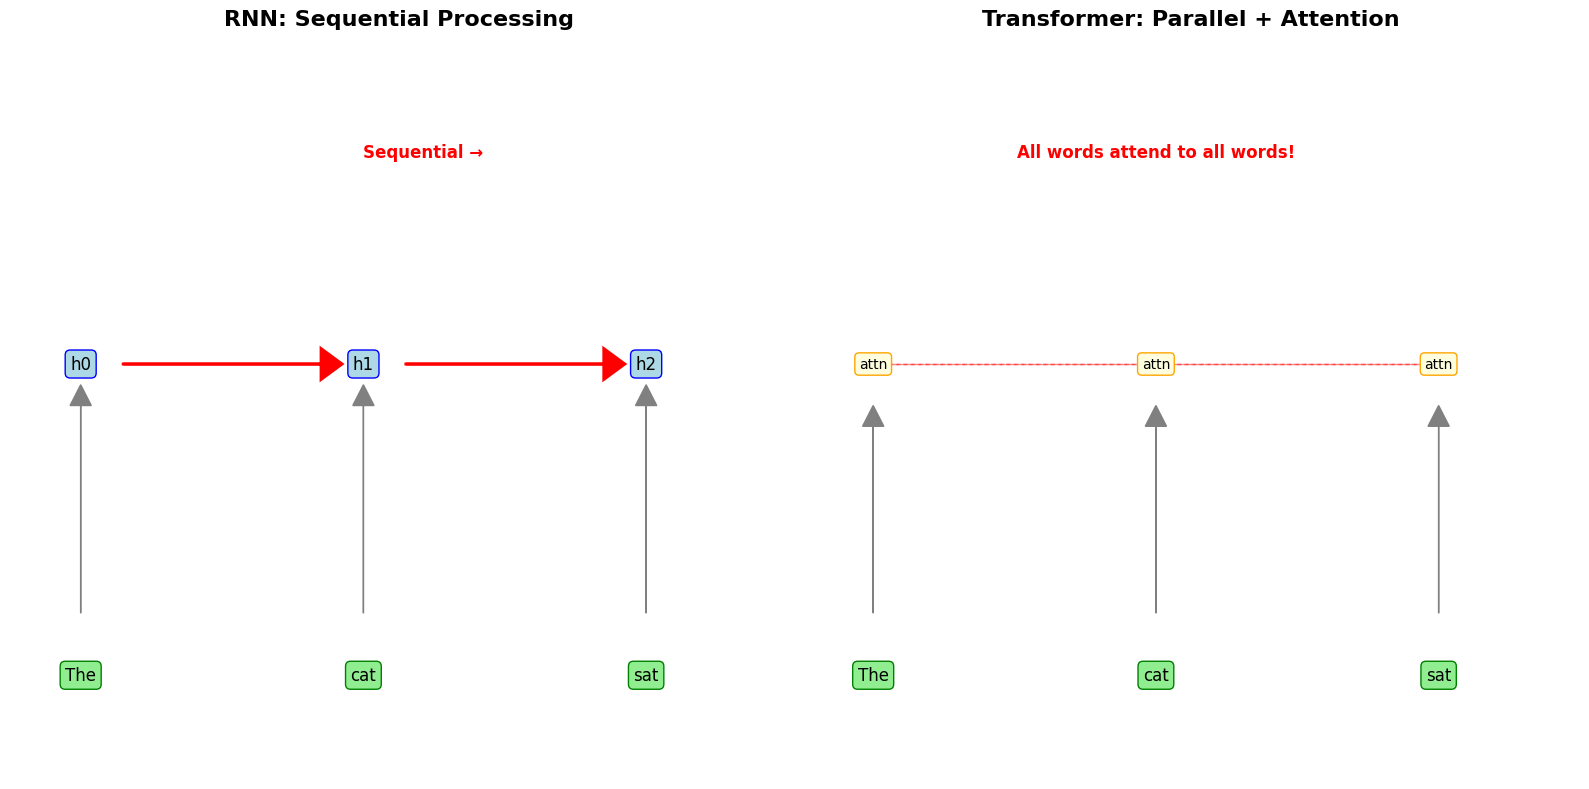

🔥 Transformer Advantages:
   • Parallel processing = faster training
   • Direct connections = better long-range dependencies
   • Attention = interpretable (see what the model focuses on!)


In [ ]:
# Visualize Transformer architecture
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# LEFT: RNN architecture
ax1.set_title('RNN: Sequential Processing', fontsize=16, fontweight='bold', pad=20)
words_rnn = ['The', 'cat', 'sat']
for i, word in enumerate(words_rnn):
    # Word
    ax1.text(i*2, 0, word, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='lightgreen', edgecolor='green'))
    # Hidden state
    ax1.text(i*2, 1.5, f'h{i}', ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='lightblue', edgecolor='blue'))
    # Arrows
    ax1.arrow(i*2, 0.3, 0, 1.0, head_width=0.15, head_length=0.1, fc='gray', ec='gray')
    if i < len(words_rnn) - 1:
        ax1.arrow(i*2+0.3, 1.5, 1.4, 0, head_width=0.15, head_length=0.15, 
                 fc='red', ec='red', linewidth=2)

ax1.text(2, 2.5, 'Sequential →', fontsize=12, color='red', fontweight='bold')
ax1.set_xlim(-0.5, 5)
ax1.set_ylim(-0.5, 3)
ax1.axis('off')

# RIGHT: Transformer architecture
ax2.set_title('Transformer: Parallel + Attention', fontsize=16, fontweight='bold', pad=20)
words_trans = ['The', 'cat', 'sat']
y_input = 0
y_attn = 1.5

for i, word in enumerate(words_trans):
    x = i * 2
    # Word
    ax2.text(x, y_input, word, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='lightgreen', edgecolor='green'))
    # Attention layer
    ax2.text(x, y_attn, f'attn', ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))
    # Up arrows
    ax2.arrow(x, y_input+0.3, 0, 0.9, head_width=0.15, head_length=0.1, fc='gray', ec='gray')

# Draw attention connections (all-to-all)
for i in range(len(words_trans)):
    for j in range(len(words_trans)):
        x1, x2 = i*2, j*2
        if i != j:
            # Curved connections
            ax2.plot([x1, x2], [y_attn, y_attn], 'r--', alpha=0.3, linewidth=1)

ax2.text(2, 2.5, 'All words attend to all words!', fontsize=12, 
        color='red', fontweight='bold', ha='center')
ax2.set_xlim(-0.5, 5)
ax2.set_ylim(-0.5, 3)
ax2.axis('off')

plt.tight_layout()
plt.show()

print("Transformer Advantages:")
print("   • Parallel processing = faster training")
print("   • Direct connections = better long-range dependencies")
print("   • Attention = interpretable (see what the model focuses on!)")
